# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

Data represents 17 campaigns

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [5]:
df['y'].value_counts(normalize=True)

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

***Business objective*** of this task is to find the best model that can explain the success of the bank marketing campaigns and the attributes that lead to the campaign's success

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [25]:
bank_info = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'y']
df_bank = df[bank_info]
df_bank.head()

,age,job,marital,education,default,housing,loan,y
0,56,housemaid,married,basic.4y,no,no,no,no
1,57,services,married,high.school,unknown,no,no,no
2,37,services,married,high.school,no,yes,no,no
3,40,admin.,married,basic.6y,no,no,no,no
4,56,services,married,high.school,no,no,yes,no


In [26]:
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        41188 non-null  int64 
 1   job        41188 non-null  object
 2   marital    41188 non-null  object
 3   education  41188 non-null  object
 4   default    41188 non-null  object
 5   housing    41188 non-null  object
 6   loan       41188 non-null  object
 7   y          41188 non-null  object
dtypes: int64(1), object(7)
memory usage: 2.5+ MB


In [8]:
for a in bank_info[1:]:
    print(f'{a}: *********')
    print(df_bank[a].value_counts(normalize=True))

job: *********
job
admin.           0.253035
blue-collar      0.224677
technician       0.163713
services         0.096363
management       0.070992
retired          0.041760
entrepreneur     0.035350
self-employed    0.034500
housemaid        0.025736
unemployed       0.024619
student          0.021244
unknown          0.008012
Name: proportion, dtype: float64
marital: *********
marital
married     0.605225
single      0.280859
divorced    0.111974
unknown     0.001942
Name: proportion, dtype: float64
education: *********
education
university.degree      0.295426
high.school            0.231014
basic.9y               0.146766
professional.course    0.127294
basic.4y               0.101389
basic.6y               0.055647
unknown                0.042027
illiterate             0.000437
Name: proportion, dtype: float64
default: *********
default
no         0.791201
unknown    0.208726
yes        0.000073
Name: proportion, dtype: float64
housing: *********
housing
yes        0.523842
no   

***Data Prepration 1*** 

There are unknown values for each of the attributes which do no provide any information. Also the proportion of these rows are comparatively quite small. Drop the rows which have unknown values

In [27]:
df_bank_clean = df_bank.loc[(df['age'] != 'unknown') & 
                            (df['job'] != 'unknown') &
                            (df['marital'] != 'unknown')] 

df_bank_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40787 entries, 0 to 41187
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        40787 non-null  int64 
 1   job        40787 non-null  object
 2   marital    40787 non-null  object
 3   education  40787 non-null  object
 4   default    40787 non-null  object
 5   housing    40787 non-null  object
 6   loan       40787 non-null  object
 7   y          40787 non-null  object
dtypes: int64(1), object(7)
memory usage: 2.8+ MB


In [28]:
df_bank_clean['default'].value_counts()

default
no         32348
unknown     8436
yes            3
Name: count, dtype: int64

***Data Preparation 2***

map unknown values in default to 'no' with assumption that defaulted accounts
would definitely be recorded as 'yes'


In [29]:
df_bank_clean = df_bank_clean.copy()
df_bank_clean['default'] = df_bank_clean['default'].map(lambda x: 'no' if x == 'unknown' else x)

In [30]:
df_bank_clean['default'].value_counts()

default
no     40784
yes        3
Name: count, dtype: int64

In [31]:
df_bank_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40787 entries, 0 to 41187
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        40787 non-null  int64 
 1   job        40787 non-null  object
 2   marital    40787 non-null  object
 3   education  40787 non-null  object
 4   default    40787 non-null  object
 5   housing    40787 non-null  object
 6   loan       40787 non-null  object
 7   y          40787 non-null  object
dtypes: int64(1), object(7)
memory usage: 2.8+ MB


In [32]:
for a in bank_info[1:]:
    print(f'{a}: *********')
    print(df_bank_clean[a].value_counts(normalize=True))

job: *********
job
admin.           0.255179
blue-collar      0.226543
technician       0.165028
services         0.097163
management       0.071616
retired          0.042048
entrepreneur     0.035624
self-employed    0.034717
housemaid        0.025915
unemployed       0.024738
student          0.021428
Name: proportion, dtype: float64
marital: *********
marital
married     0.605438
single      0.281805
divorced    0.112757
Name: proportion, dtype: float64
education: *********
education
university.degree      0.296565
high.school            0.232035
basic.9y               0.147253
professional.course    0.128105
basic.4y               0.100964
basic.6y               0.055508
unknown                0.039130
illiterate             0.000441
Name: proportion, dtype: float64
default: *********
default
no     0.999926
yes    0.000074
Name: proportion, dtype: float64
housing: *********
housing
yes        0.524089
no         0.451786
unknown    0.024125
Name: proportion, dtype: float64
loan: *

In [33]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer

In [34]:
education_order = [
    'illiterate',
    'basic.4y',
    'basic.6y',
    'basic.9y',
    'unknown',
    'high.school',
    'professional.course',
    'university.degree'
]

transformer = make_column_transformer((OneHotEncoder(drop='if_binary', sparse_output=False), 
                                       ['job', 'marital', 'default', 'housing', 'loan', 'y']),
                               (OrdinalEncoder(categories=[education_order]), ['education']),
                                remainder='passthrough')
t_data = transformer.fit_transform(df_bank_clean)
feature_names = [feature.split('__')[1] for feature in transformer.get_feature_names_out()]
df_bank_clean = pd.DataFrame(t_data, columns=feature_names)



In [35]:

df_bank_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40787 entries, 0 to 40786
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   job_admin.         40787 non-null  float64
 1   job_blue-collar    40787 non-null  float64
 2   job_entrepreneur   40787 non-null  float64
 3   job_housemaid      40787 non-null  float64
 4   job_management     40787 non-null  float64
 5   job_retired        40787 non-null  float64
 6   job_self-employed  40787 non-null  float64
 7   job_services       40787 non-null  float64
 8   job_student        40787 non-null  float64
 9   job_technician     40787 non-null  float64
 10  job_unemployed     40787 non-null  float64
 11  marital_divorced   40787 non-null  float64
 12  marital_married    40787 non-null  float64
 13  marital_single     40787 non-null  float64
 14  default_yes        40787 non-null  float64
 15  housing_no         40787 non-null  float64
 16  housing_unknown    407

In [36]:
df_bank_clean.rename(columns={'y_yes':'y'}, inplace=True)

In [37]:
df_bank_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40787 entries, 0 to 40786
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   job_admin.         40787 non-null  float64
 1   job_blue-collar    40787 non-null  float64
 2   job_entrepreneur   40787 non-null  float64
 3   job_housemaid      40787 non-null  float64
 4   job_management     40787 non-null  float64
 5   job_retired        40787 non-null  float64
 6   job_self-employed  40787 non-null  float64
 7   job_services       40787 non-null  float64
 8   job_student        40787 non-null  float64
 9   job_technician     40787 non-null  float64
 10  job_unemployed     40787 non-null  float64
 11  marital_divorced   40787 non-null  float64
 12  marital_married    40787 non-null  float64
 13  marital_single     40787 non-null  float64
 14  default_yes        40787 non-null  float64
 15  housing_no         40787 non-null  float64
 16  housing_unknown    407

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
X, y = df_bank_clean.drop('y', axis=1), df_bank_clean['y']
X.head()

,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,marital_single,default_yes,housing_no,housing_unknown,housing_yes,loan_no,loan_unknown,loan_yes,education,age
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,56.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,5.0,57.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,5.0,37.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,2.0,40.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,5.0,56.0


In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, stratify=y)
X_train = X_train.values
X_test = X_test.values
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((27327, 23), (27327,), (13460, 23), (13460,))

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

***Baseline***

Use the basic majority class proportion as baseline, i.e. if we randomly guess the class based on the proportion of the classes, we would get 87% success. So the trained classifier models should beat at least this baseline which is 87%

normalized value_counts of y column:
    
    no     0.887366
    yes    0.112634
    

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from time import time

In [42]:
lr_pipe = Pipeline([('scaler', StandardScaler()),
                    ('lr', LogisticRegression())])
lr_start_time = time()
lr_pipe.fit(X_train, y_train)
lr_end_time = time()
lr_train_time = lr_end_time - lr_start_time

### Problem 9: Score the Model

What is the accuracy of your model?

In [43]:
lr_train_accuracy = lr_pipe.score(X_train, y_train)
lr_test_accuracy = lr_pipe.score(X_test, y_test)
lr_train_time, lr_train_accuracy, lr_test_accuracy

(0.04241204261779785, 0.887364145350752, 0.887369985141159)

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [44]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [45]:
classifiers = [LogisticRegression(), KNeighborsClassifier(), DecisionTreeClassifier(), SVC()]
model = ['LogisticRegression', 'KNearestNeighbors', 'DecisionTree', 'SVM']
train_time = []
train_accuracy = []
test_accuracy = []

for classifier in classifiers:
    pipe = Pipeline([('scaler', StandardScaler()), 
                    ('classifier', classifier)])
    start_time = time()
    pipe.fit(X_train, y_train)
    end_time = time()
    train_time.append(end_time - start_time)
    train_accuracy.append(pipe.score(X_train, y_train))
    test_accuracy.append(pipe.score(X_test, y_test))

train_time, train_accuracy, test_accuracy

([0.043389081954956055,
  0.007978200912475586,
  0.04232192039489746,
  7.310917139053345],
 [0.887364145350752,
  0.8905844037032971,
  0.9144435905880631,
  0.887364145350752],
 [0.887369985141159,
  0.8782317979197622,
  0.8669390787518574,
  0.887369985141159])

In [46]:
model_df = pd.DataFrame({'Model': model,
                         'Train Time': train_time,
                         'Train Accuracy': train_accuracy,
                         'Test Accuracy': test_accuracy})
#model_df = model_df.set_index('Model')
model_df

,Model,Train Time,Train Accuracy,Test Accuracy
0,LogisticRegression,0.043389,0.887364,0.887370
1,KNearestNeighbors,0.007978,0.890584,0.878232
2,DecisionTree,0.042322,0.914444,0.866939
3,SVM,7.310917,0.887364,0.887370


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

**Note**

In addition to accuracy we will also track ROC-AUC as another metric for these models. For the classifiers it is important to look at the FPR and TPR to see how effective the models are

In [47]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

In [49]:
import numpy as np

In [62]:
# grid search across 'penalty' and 'C' values for logistic regression
lgr_params = {'lgr__penalty': ['l1', 'l2'],
              'lgr__C': np.linspace(0.0001, 1, 10)}
              

In [63]:
lgr_pipe = Pipeline([('scaler', StandardScaler()),
                     ('lgr', LogisticRegression(random_state=42, max_iter=10_000, solver='liblinear'))])
lgr_grid = GridSearchCV(lgr_pipe, param_grid=lgr_params, cv=5)
lgr_grid_start_time = time()
lgr_grid.fit(X_train, y_train)
lgr_grid_end_time = time()

In [64]:
lgr_grid_train_time = lgr_grid_end_time - lgr_grid_start_time
lgr_grid_train_accuracy = lgr_grid.best_estimator_.score(X_train, y_train)
lgr_grid_test_accuracy = lgr_grid.best_estimator_.score(X_test, y_test)

lgr_grid_roc_auc = float(roc_auc_score(y_test, lgr_grid.best_estimator_.predict_proba(X_test)[:, 1]))

print(lgr_grid.best_params_)
lgr_grid_train_time, lgr_grid_train_accuracy, lgr_grid_test_accuracy, lgr_grid_roc_auc

{'lgr__C': np.float64(0.0001), 'lgr__penalty': 'l1'}


(5.37540078163147, 0.887364145350752, 0.887369985141159, 0.5)

In [65]:
def DisplayRocCurve(estimator, title):
    plt.figure(figsize=(8,6))
    RocCurveDisplay.from_estimator(estimator, X_test, y_test, ax=plt.gca())

    plt.title(title)
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.grid(True)
    plt.show()


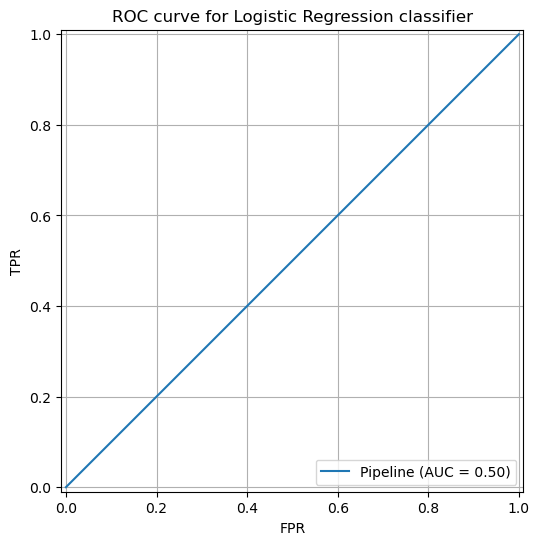

In [66]:
DisplayRocCurve(lgr_grid.best_estimator_, 'ROC curve for Logistic Regression classifier')

In [67]:
#Decision Tree Classifier

dtree_params = {
         'dtree__max_depth': range(2,11),
         'dtree__min_samples_split': [2, 4, 6],
         'dtree__criterion': ['gini', 'entropy', 'log_loss'],
         'dtree__min_samples_leaf': [1, 2, 3]
         }

In [68]:
dtree_pipe = Pipeline([('scaler', StandardScaler()), 
                       ('dtree', DecisionTreeClassifier())])
dtree_grid = GridSearchCV(dtree_pipe, param_grid=dtree_params, cv=5)
dtree_start_time = time()
dtree_grid.fit(X_train, y_train)
dtree_end_time = time()

In [69]:
dtree_grid_train_time = dtree_end_time - dtree_start_time
dtree_grid_train_accuracy = dtree_grid.best_estimator_.score(X_train, y_train)
dtree_grid_test_accuracy = dtree_grid.best_estimator_.score(X_test, y_test)
dtree_grid_roc_auc_score = float(roc_auc_score(y_test, dtree_grid.best_estimator_.predict_proba(X_test)[:, 1]))

print(dtree_grid.best_params_)
dtree_grid_train_time, dtree_grid_train_accuracy, dtree_grid_test_accuracy, dtree_grid_roc_auc_score

{'dtree__criterion': 'gini', 'dtree__max_depth': 2, 'dtree__min_samples_leaf': 1, 'dtree__min_samples_split': 2}


(18.566829919815063, 0.887364145350752, 0.887369985141159, 0.5583158135061246)

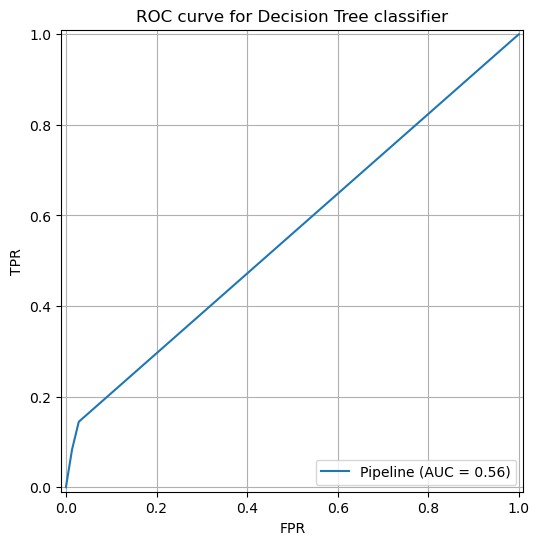

In [70]:
DisplayRocCurve(dtree_grid.best_estimator_, 'ROC curve for Decision Tree classifier')

In [252]:
from sklearn.neighbors import KNeighborsClassifier

In [71]:
# knn

knn_params = {'knn__n_neighbors': list(range(1,30,2))}

In [72]:
knn_pipe = Pipeline([('scaler', StandardScaler()), 
                       ('knn', KNeighborsClassifier())])
knn_grid = GridSearchCV(knn_pipe, param_grid=knn_params, cv=5)
knn_start_time = time()
knn_grid.fit(X_train, y_train)
knn_end_time = time()

In [73]:
knn_grid_train_time = knn_end_time - knn_start_time
knn_grid_train_accuracy = knn_grid.best_estimator_.score(X_train, y_train)
knn_grid_test_accuracy = knn_grid.best_estimator_.score(X_test, y_test)
knn_grid_roc_auc_score = float(roc_auc_score(y_test, knn_grid.best_estimator_.predict_proba(X_test)[:,1]))
print(knn_grid.best_params_)
knn_grid_train_time, knn_grid_train_accuracy, knn_grid_test_accuracy, knn_grid_roc_auc_score

{'knn__n_neighbors': 19}


(4.695481061935425, 0.8882789914736341, 0.8869242199108469, 0.5956728364734636)

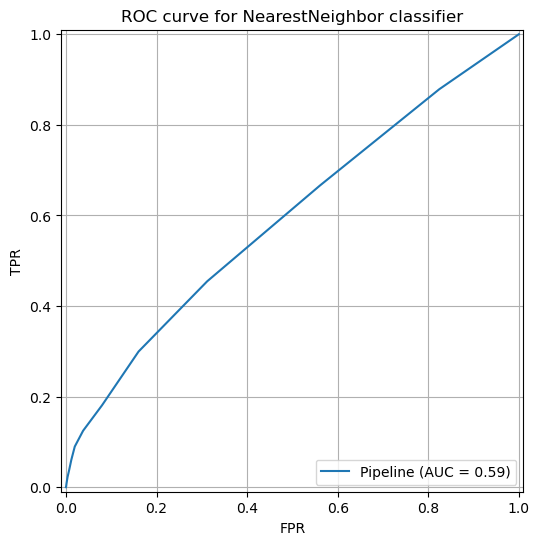

In [256]:
DisplayRocCurve(knn_grid.best_estimator_, 'ROC curve for NearestNeighbor classifier')

In [74]:
from sklearn.svm import SVC

In [75]:
# svm
svm_params = {'svc__kernel': ['linear', 'poly', 'rbf', 'sigmoid']}

In [76]:
svm_pipe = Pipeline([('scaler', StandardScaler()), 
                       ('svc', SVC(probability=True))])
svm_grid = GridSearchCV(svm_pipe, param_grid=svm_params, cv=5)
svm_start_time = time()
svm_grid.fit(X_train, y_train)
svm_end_time = time()

{'svc__kernel': 'linear'}


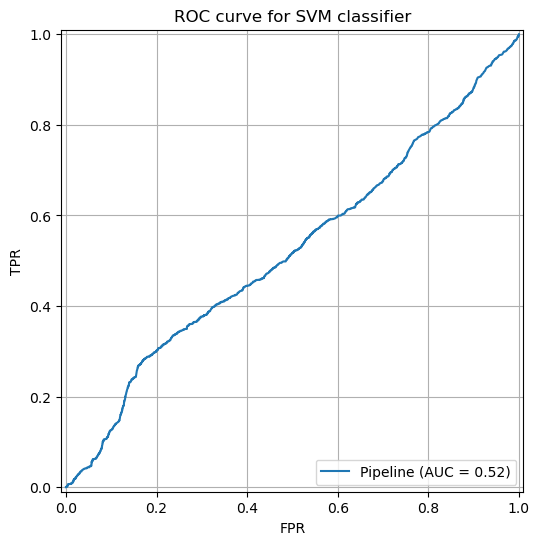

(1694.9290981292725,
 0.8734456085381377,
 0.8733850129198967,
 0.5212744169479002)

In [182]:
svm_grid_train_time = svm_end_time - svm_start_time
svm_grid_train_accuracy = svm_grid.best_estimator_.score(X_train, y_train)
svm_grid_test_accuracy = svm_grid.best_estimator_.score(X_test, y_test)
svm_grid_roc_auc_score = float((roc_auc_score(y_test, svm_grid.best_estimator_.predict_proba(X_test)[:,1])))
print(svm_grid.best_params_)
DisplayRocCurve(svm_grid.best_estimator_, 'ROC curve for SVM classifier')
svm_grid_train_time, svm_grid_train_accuracy, svm_grid_test_accuracy, svm_grid_roc_auc_score

##### Questions